# Parallel execution: 번역 후보 비교

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ksmin23/agent-pattern-examples/blob/feat/workflow-planning-colab/patterns/parallel_execution/examples/translation_candidates/notebooks/parallel_execution-ko.ipynb)

**대상:** Python 함수와 async/await에 익숙한 Agent 입문자.

**학습 목표:** 3개 후보 병렬 생성 → 결과 수집 → 최적 후보 선택 과정을 Agent 정의와 실행 셀로 직접 구성합니다.

**순서:** 환경 준비 → 입력·Agent 정의 → 실행 → 결과 확인 → 작은 실습.

소스 코드 · 예제 안내 · 환경 설정

### 패턴 구조

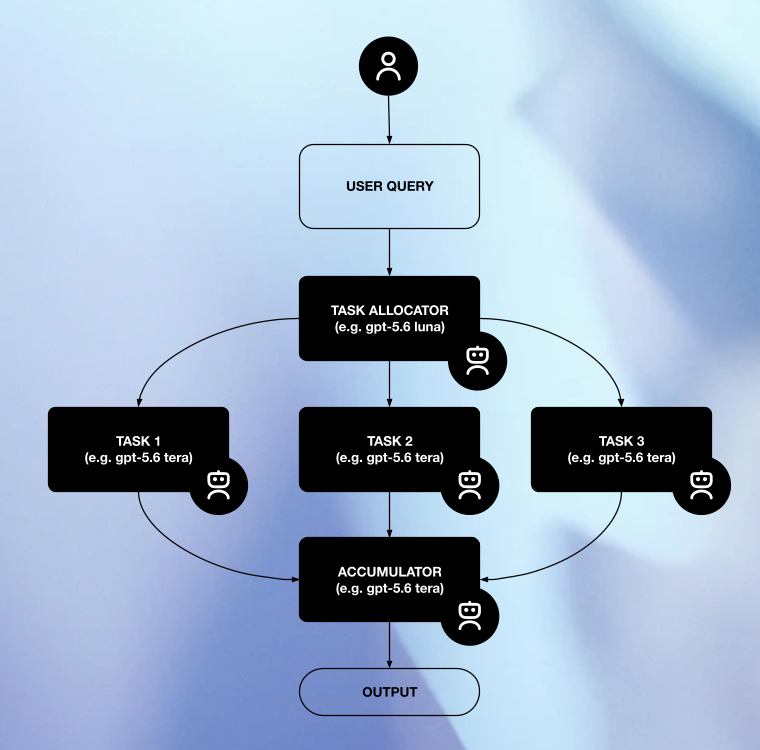

### 그림을 코드로 읽기

| 그림의 구성 요소 | 코드 구현 | 역할 |
| --- | --- | --- |
| User Query | `message` | 번역할 원문 |
| Task Allocator | 리스트 내포와 `asyncio.gather()` | 동일한 작업을 여러 실행으로 분배 |
| Tasks | `Runner.run(translator, ...)` | 번역 후보를 병렬 생성 |
| Accumulator | `picker` | 후보를 비교하고 최적 결과를 선택 |
| Output | `best.final_output` | 선택된 번역과 선택 이유 |

#### 실행 흐름

1. `CANDIDATES` 수만큼 `Runner.run()` 코루틴을 만듭니다.
2. `asyncio.gather()`가 번역 요청을 동시에 실행합니다.
3. 완료된 결과를 `translations`에 모읍니다.
4. `picker`가 전체 후보를 비교해 하나를 선택합니다.

#### 그림과 이 예제의 차이

그림의 Task Allocator는 별도 Agent처럼 보이지만, 이 예제에서는 Python 코드가 분배를 담당합니다. Task 1~3도 서로 다른 전문 Agent가 아니라 동일한 `translator` Agent의 독립 실행입니다.

## 1. 환경 준비

### Colab

1. 이 `.ipynb` 파일을 Colab의 **파일 → 노트북 업로드**로 엽니다. 저장소 복제나 Google Drive 마운트는 필요하지 않습니다. CPU 런타임으로 실행할 수 있습니다.
2. 아래 설정 셀이 `openai-agents==0.22.1`과 `python-dotenv`를 필요한 경우 설치합니다. 이미 다른 SDK 버전을 import했다면 런타임을 다시 시작한 뒤 위에서부터 실행하세요.
3. 실제 API 실행을 원하면 왼쪽 **Secrets(열쇠 아이콘)**에 기존 키를 `OPENAI_API_KEY` 이름으로 등록하고 이 Notebook의 접근 권한을 켭니다. 키를 코드 셀에 붙여넣지 마세요. 로컬 `.env.local`은 Colab에 자동 전달되지 않습니다.

### 로컬 Jupyter

`uv`로 공통 Notebook 환경을 설치한 뒤 해당 커널을 선택하세요. 기존 환경 변수를 우선 사용하며, 현재 위치 또는 상위 디렉터리에 `.env.local`이 있으면 추가 설정을 읽습니다. 오프라인 실습에는 `.env.local`이나 API 키가 필요하지 않습니다.

### 실행 설정

기본 `RUN_API=False`에서는 Secrets 조회와 API 호출 없이 Agent 구성과 오프라인 실습을 실행합니다. API 결과를 보려면 다음 셀에서 `RUN_API=True`로 변경하고 아래 셀을 순서대로 실행하세요. 키는 **환경 변수 → 선택적 `.env.local` → Colab Secrets** 순서로 찾으며 값을 출력하거나 파일에 저장하지 않습니다. 모델 호출 및 웹 검색에는 비용이 발생할 수 있습니다. Notebook에서는 `asyncio.run()` 대신 최상위 `await`를 사용합니다.

후반 독립 실행 예제는 별도의 `run_api=True` 인수로 활성화합니다. 앞부분의 `RUN_API` 변경은 이 인수에 적용되지 않습니다.


In [ ]:
import os
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

# Install only in Colab. Local environments use requirements-notebooks.txt.
try:
    import google.colab
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    try:
        dependencies_ready = (
            version("openai-agents") == "0.22.1"
            and version("python-dotenv").split(".")[0] == "1"
        )
    except PackageNotFoundError:
        dependencies_ready = False
    if not dependencies_ready:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--quiet",
            "openai-agents==0.22.1", "python-dotenv>=1,<2",
        ])

from agents import Agent, Runner, set_tracing_disabled
from dotenv import find_dotenv, load_dotenv


def load_environment(*, run_api: bool) -> str:
    """Load optional local settings; request Colab Secrets only for live runs."""
    env_path = find_dotenv(filename=".env.local", usecwd=True)
    if env_path:
        load_dotenv(env_path, override=False)

    if run_api and not os.getenv("OPENAI_API_KEY", "").strip():
        try:
            from google.colab import userdata
        except ImportError:
            raise RuntimeError(
                "Set OPENAI_API_KEY in your environment or .env.local before enabling API calls."
            ) from None

        try:
            key = userdata.get("OPENAI_API_KEY")
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError, userdata.TimeoutException):
            raise RuntimeError(
                "In Colab Secrets, add OPENAI_API_KEY and enable Notebook access, "
                "then rerun this cell."
            ) from None
        if not isinstance(key, str) or not key.strip():
            raise RuntimeError("The OPENAI_API_KEY secret is empty.")
        os.environ["OPENAI_API_KEY"] = key.strip()

    return os.getenv("AGENT_MODEL", "gpt-5.6-luna")


RUN_API = False  # Set True for the walkthrough's API and web search calls.
MODEL = load_environment(run_api=RUN_API)
set_tracing_disabled(True)
print({"environment": "Colab" if IN_COLAB else "local", "model": MODEL, "api_enabled": RUN_API})


## 2. 생성 Agent와 선택 Agent

독립적인 번역 호출들을 병렬로 실행하고, 모든 결과가 도착한 뒤 선택합니다.

In [ ]:
import asyncio
import time

translator = Agent(
    name="Spanish translator",
    model=MODEL,
    instructions="Translate the input into Spanish. Return only the translation.",
)

picker = Agent(
    name="Translation picker",
    model=MODEL,
    instructions=(
        "Choose the best Spanish translation. Return the chosen translation "
        "and a short reason."
    ),
)

message = "Good morning! Welcome to our agent workshop."
CANDIDATES = 3

assert 1 <= CANDIDATES <= 5

## 3. 병렬 생성과 종합 · API 호출

`asyncio.gather()`는 입력 순서대로 결과를 반환합니다. 이 예제는 한 호출이 실패하면 오류를 전파하며, 부분 실패 복구는 별도 구현 범위입니다.

In [ ]:
translations = []
best = None

if RUN_API:
    started = time.perf_counter()
    results = await asyncio.gather(
        *[Runner.run(translator, message, max_turns=2) for _ in range(CANDIDATES)]
    )
    translations = [str(result.final_output) for result in results]
    best = await Runner.run(
        picker,
        f"Original: {message}\nCandidates: {translations}",
        max_turns=2,
    )
    elapsed = time.perf_counter() - started

    for index, value in enumerate(translations, 1):
        print(f"{index}. {value}")

    print("Selected:", best.final_output)
    print(f"Total elapsed time: {elapsed:.1f}s")
else:
    print("API call skipped")

## 4. 결과 확인

응답 개수와 비어 있지 않은 결과를 확인합니다. 같은 모델이 동일한 번역을 반환할 수도 있습니다.

In [ ]:
if best is not None:
    assert len(translations) == CANDIDATES
    assert all(text.strip() for text in translations)
    assert str(best.final_output).strip()

## 5. 별도 파일로 구성하기: `main()` 실행 진입점

앞의 단계별 코드는 그대로 두고, 같은 실행 흐름을 하나의 Python 모듈로 구성합니다. 아래 함수 정의는 앞에서 만든 Agent나 전역 변수에 의존하지 않으므로, 필요한 패키지가 설치되어 있다면 이 코드 셀부터 실행할 수 있습니다.

**동일한 번역 Agent를 여러 번 병렬 실행한 뒤, 선택 Agent가 결과를 비교하는 워크플로**를 함수로 묶습니다. 별도의 작업 분배 Agent를 추가하는 구조는 아닙니다.

| 구성 | 책임 |
| --- | --- |
| `build_translation_agents()` | 번역 Agent와 선택 Agent 구성 |
| `translate_and_select()` | 후보 병렬 생성 → 결과 수집 → 최종 선택 |
| `main()` | 환경 설정, 입력 전달, 결과 출력 |

`main(run_api=...)`로 API 실행 여부를 지정합니다. 기본값은 `False`이며, 함수 정의 셀만 실행하면 API를 호출하지 않습니다. 실제 실행에서는 후보 수만큼의 생성 호출과 한 번의 선택 호출이 발생합니다. 후보 수가 늘면 비용도 증가할 수 있습니다.


In [ ]:
import asyncio
import os
import time

from agents import Agent, Runner, set_tracing_disabled
from dotenv import find_dotenv, load_dotenv


def build_translation_agents(model: str) -> tuple[Agent, Agent]:
    """Create the translator and picker for one workflow run."""
    translator = Agent(
        name="Spanish translator",
        model=model,
        instructions="Translate the input into Spanish. Return only the translation.",
    )

    picker = Agent(
        name="Translation picker",
        model=model,
        instructions=(
            "Choose the best Spanish translation. Return the chosen translation "
            "and a short reason."
        ),
    )

    return translator, picker


async def translate_and_select(
    message: str,
    *,
    model: str,
    candidates: int = 3,
) -> dict:
    """Generate translations concurrently, then select the best candidate."""
    if not 1 <= candidates <= 5:
        raise ValueError("candidates must be between 1 and 5.")

    translator, picker = build_translation_agents(model)
    started = time.perf_counter()

    results = await asyncio.gather(
        *[
            Runner.run(translator, message, max_turns=2)
            for _ in range(candidates)
        ]
    )
    translations = [str(result.final_output) for result in results]

    best = await Runner.run(
        picker,
        f"Original: {message}\nCandidates: {translations}",
        max_turns=2,
    )
    elapsed = time.perf_counter() - started

    return {
        "translations": translations,
        "selected": str(best.final_output),
        "elapsed_seconds": elapsed,
    }


def load_environment(*, run_api: bool) -> str:
    """Load optional local settings; request Colab Secrets only for live runs."""
    env_path = find_dotenv(filename=".env.local", usecwd=True)
    if env_path:
        load_dotenv(env_path, override=False)

    if run_api and not os.getenv("OPENAI_API_KEY", "").strip():
        try:
            from google.colab import userdata
        except ImportError:
            raise RuntimeError(
                "Set OPENAI_API_KEY in your environment or .env.local before enabling API calls."
            ) from None

        try:
            key = userdata.get("OPENAI_API_KEY")
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError, userdata.TimeoutException):
            raise RuntimeError(
                "In Colab Secrets, add OPENAI_API_KEY and enable Notebook access, "
                "then rerun this cell."
            ) from None
        if not isinstance(key, str) or not key.strip():
            raise RuntimeError("The OPENAI_API_KEY secret is empty.")
        os.environ["OPENAI_API_KEY"] = key.strip()

    return os.getenv("AGENT_MODEL", "gpt-5.6-luna")


async def main(
    message: str = "Good morning! Welcome to our agent workshop.",
    *,
    run_api: bool = False,
    candidates: int = 3,
) -> dict | None:
    """Load configuration, run the workflow, and present its results."""
    model = load_environment(run_api=run_api)
    set_tracing_disabled(True)

    if not run_api:
        print("API call skipped. Pass run_api=True to enable it.")
        return None

    result = await translate_and_select(
        message,
        model=model,
        candidates=candidates,
    )

    for index, translation in enumerate(result["translations"], 1):
        print(f"{index}. {translation}")

    print("Selected:", result["selected"])
    print(f"Total elapsed time: {result['elapsed_seconds']:.1f}s")

    return result


### Notebook에서 호출하기

Jupyter에서는 `asyncio.run()` 대신 `await main(...)`을 사용합니다. 아래 셀은 기본적으로 API 호출을 생략합니다. 실습할 때 `run_api=True`로 바꾸세요. 앞의 단계별 실습과는 별도의 새 실행입니다.


In [ ]:
standalone_result = await main(
    message="Good morning! Welcome to our agent workshop.",
    run_api=False,  # Set to True to run this standalone workflow.
    candidates=3,
)


### `translation_agent.py` 파일로 실행하기

1. 위의 **함수 정의 코드 셀 전체**를 `translation_agent.py`에 복사합니다. Notebook 전용 `await main(...)` 호출 셀은 복사하지 않습니다.

2. 파일 맨 아래에 다음 진입점을 추가합니다. `--run-api`를 지정한 경우에만 API를 호출합니다.

   ```python
   if __name__ == "__main__":
       import argparse

       parser = argparse.ArgumentParser(description="Compare translation candidates.")
       parser.add_argument("--run-api", action="store_true")
       args = parser.parse_args()

       asyncio.run(main(run_api=args.run_api))
   ```

3. 공통 실습 의존성이 설치된 가상환경을 활성화하고, 실행합니다. API 호출 시 환경 변수 또는 선택적 `.env.local`에 `OPENAI_API_KEY`를 설정합니다.

   ```bash
   python translation_agent.py            # Check configuration; skip API calls
   python translation_agent.py --run-api  # Run the workflow; API costs apply
   ```

다른 모듈에서는 `from translation_agent import translate_and_select`로 가져와 `await translate_and_select(message, model=..., candidates=3)`을 호출합니다. 이 경우 환경 변수와 tracing 설정은 호출하는 애플리케이션에서 준비합니다. 진입점의 `if __name__ == "__main__":` 조건 때문에 import만으로 실행되지 않습니다.

`asyncio.gather()`는 완료 순서와 관계없이 입력 순서대로 결과를 반환하며, 모든 후보 생성이 성공한 뒤 선택 Agent를 실행합니다. 후보 호출이 실패하면 오류를 호출자에게 전달합니다. 자동 재시도·부분 결과 선택·나머지 작업 취소는 별도로 설계해야 합니다. 같은 Agent를 반복 호출하므로 후보의 다양성을 보장하지 않습니다.

이 추가 예제는 기존 `src/main.py`를 수정하거나 덮어쓰지 않습니다. 파일을 배포할 때는 이 Notebook의 출처와 저장소의 `THIRD_PARTY_NOTICES.md` 고지도 함께 유지하세요.


## 직접 바꿔보기

후보 수를 2 또는 4로 바꾸고 결과의 다양성을 비교하세요. 시간 비교 시 후보 수와 모델을 기록하세요. 이 한 번의 측정만으로 병렬화의 속도 개선을 단정하지 마세요.

## 원본과 달라진 점 · 주의점

공식 예제의 병렬 생성·선택 흐름을 유지하고, 입력과 후보 수를 셀에서 설정하도록 바꿨습니다. 후보 수가 늘면 모델 호출 수도 늘어납니다.

## 출처

- [로컬 소스](../src/main.py)
- [OpenAI 공식 예제](https://github.com/openai/openai-agents-python/blob/25af629b3c877ba3d0e95189141bb636b21167a5/examples/agent_patterns/parallelization.py)
- [Agents SDK 가이드](https://developers.openai.com/api/docs/guides/agents/sdk)
- [Agents 가이드](https://developers.openai.com/api/docs/guides/agents)

이 Notebook은 공식 예제를 학습용으로 재구성한 파일이며 원본의 단순 복사본은 아닙니다. 모델 출력은 실행마다 달라집니다.